# Multimodal Analysis

In [ ]:
import io
import os
import sys
import zipfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_DIR = Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

DATASETS_DIR = PROJECT_DIR.parent / "datasets"
if not DATASETS_DIR.exists():
    DATASETS_DIR = PROJECT_DIR / "datasets"

TEXT_CSV = DATASETS_DIR / "unstructured_data.csv"
IMAGE_DIR = DATASETS_DIR / "images"

# LMVD (video) paths — Figshare extract uses Video_feature / Audio_feature
REPO = "helang818/LMVD"
RAW_BASE = f"https://raw.githubusercontent.com/{REPO}/main"

DATA_DIR = Path("data")
LABEL_DIR = DATA_DIR / "label"
VIDEO_FEATURE_DIR = DATA_DIR / "Video_feature"
AUDIO_FEATURE_DIR = DATA_DIR / "Audio_feature"
AUDIO_RAW_DIR = DATA_DIR / "audio"

OUTPUT_DIR = Path("outputs")
VIS_DIR = OUTPUT_DIR / "visuals"

for path in (DATA_DIR, OUTPUT_DIR, VIS_DIR):
    path.mkdir(exist_ok=True)

print(f"Text CSV:  {TEXT_CSV} ({'found' if TEXT_CSV.exists() else 'missing'})")
print(f"Images:    {IMAGE_DIR} ({'found' if IMAGE_DIR.exists() else 'missing'})")
print(f"LMVD data: {DATA_DIR}")

## 1. Text Dataset

In [ ]:
from analysis.datasets import load_text_data

TEXT_SAMPLE = 10_000
text_df = load_text_data(sample=TEXT_SAMPLE, add_aosp=True)

print(f"Loaded {len(text_df):,} text posts (sample of full corpus)")
print(text_df["status"].value_counts().head(8))
print(f"\nWell-being decline rate: {text_df['wellbeing_decline'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
status_counts = text_df["status"].value_counts().head(8)
axes[0].barh(status_counts.index[::-1], status_counts.values[::-1], color="#4C72B0")
axes[0].set_title("Top mental-health labels")
axes[0].set_xlabel("Count")

axes[1].hist(text_df["aosp_composite"], bins=40, alpha=0.7, label="AOSP composite", color="#DD8452")
axes[1].hist(text_df.loc[text_df["wellbeing_decline"] == 1, "aosp_composite"], bins=40, alpha=0.5, label="Distress", color="#C44E52")
axes[1].set_title("AOSP score distribution")
axes[1].set_xlabel("AOSP composite")
axes[1].legend()
plt.tight_layout()
plt.show()

text_df[["text", "status", "aosp_composite", "distress_score", "paradox_index"]].head(5)

## 2. Image Dataset

In [ ]:
from analysis.datasets import load_image_index

image_df = load_image_index()
print(f"Images indexed: {len(image_df)}")
if not image_df.empty:
    print(image_df["class"].value_counts())

if image_df.empty:
    print("No images found. Add files under datasets/images/{class}/")
else:
    preview = image_df.groupby("class", group_keys=False).apply(
        lambda g: g.sample(n=min(4, len(g)), random_state=42)
    )
    classes = sorted(preview["class"].unique())
    fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.8 * len(classes)))
    if len(classes) == 1:
        axes = np.array([axes])
    for row, class_name in enumerate(classes):
        subset = preview[preview["class"] == class_name]
        for col in range(4):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(subset):
                path = Path(subset.iloc[col]["path"])
                ax.imshow(Image.open(path))
                ax.set_title(class_name if col == 0 else "", fontsize=11, loc="left")
    fig.suptitle("Sample images per class", y=1.01)
    plt.tight_layout()
    plt.show()



## 3. LMVD Video Dataset


### 3.1 Download Labels from GitHub

In [30]:
def download_labels(label_dir: Path = LABEL_DIR) -> Path:
    """Download and extract label.zip from the LMVD GitHub repo."""
    label_dir.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "label.zip"

    if not any(label_dir.glob("*_Depression.csv")):
        print("Downloading labels from GitHub...")
        with urlopen(f"{RAW_BASE}/label/label.zip") as response:
            zip_path.write_bytes(response.read())

        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(label_dir)
        print(f"Extracted {len(list(label_dir.glob('*_Depression.csv')))} label files.")
    else:
        print(f"Labels already present ({len(list(label_dir.glob('*_Depression.csv')))} files).")

    return label_dir


download_labels()

Labels already present (1823 files).


WindowsPath('data/label')

### 3.2 Build Label DataFrame

In [31]:
def load_labels(label_dir: Path = LABEL_DIR) -> pd.DataFrame:
    """Load per-sample depression labels into a single DataFrame."""
    records = []
    for csv_path in sorted(label_dir.glob("*_Depression.csv"), key=lambda p: int(p.stem.split("_")[0])):
        sample_id = int(csv_path.stem.split("_")[0])
        df = pd.read_csv(csv_path)
        label = int(df.columns[0])
        records.append({"sample_id": sample_id, "label": label, "class": "Depression" if label == 1 else "Normal"})

    labels_df = pd.DataFrame(records)
    labels_df["sample_id"] = labels_df["sample_id"].astype(int)
    return labels_df


labels_df = load_labels()
labels_df.head(10)

,sample_id,label,class
0,1,1,Depression
1,2,1,Depression
2,3,1,Depression
3,4,1,Depression
4,5,1,Depression
5,6,1,Depression
6,7,1,Depression
7,8,1,Depression
8,9,1,Depression
9,10,1,Depression


In [32]:
print(f"Total samples: {len(labels_df)}")
print(labels_df["class"].value_counts())
print(f"\nClass balance: {labels_df['label'].mean():.1%} depression")

Total samples: 1823
class
Normal        915
Depression    908
Name: count, dtype: int64

Class balance: 49.8% depression


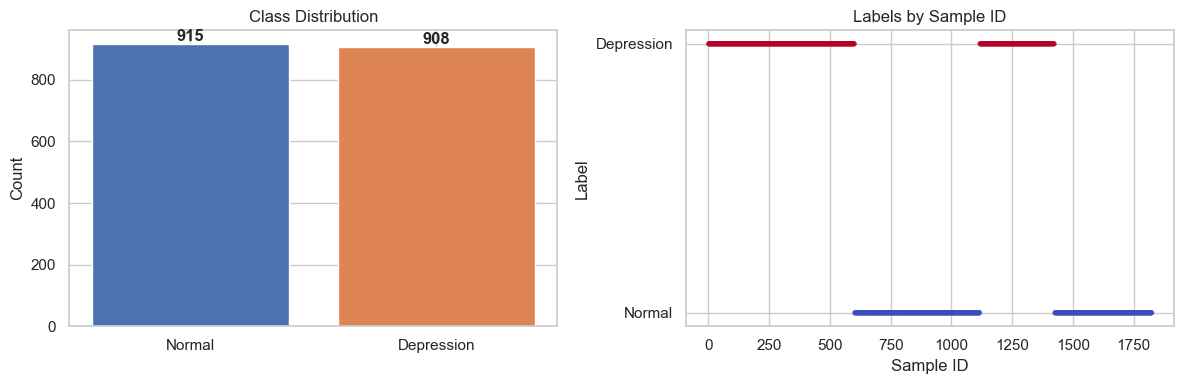

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
class_counts = labels_df["class"].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Label over sample ID (sorted)
axes[1].scatter(labels_df["sample_id"], labels_df["label"], alpha=0.3, s=8, c=labels_df["label"], cmap="coolwarm")
axes[1].set_title("Labels by Sample ID")
axes[1].set_xlabel("Sample ID")
axes[1].set_ylabel("Label")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Normal", "Depression"])

plt.tight_layout()
plt.show()

### 3.3 Train / Validation / Test Split

In [20]:
from sklearn.model_selection import StratifiedKFold, train_test_split

# 7:1:2 split (train / val / test)
train_df, temp_df = train_test_split(
    labels_df, test_size=0.3, stratify=labels_df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=2 / 3, stratify=temp_df["label"], random_state=42
)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test", "total"],
    "n_samples": [len(train_df), len(val_df), len(test_df), len(labels_df)],
    "depression_pct": [
        train_df["label"].mean(),
        val_df["label"].mean(),
        test_df["label"].mean(),
        labels_df["label"].mean(),
    ],
})
split_summary["depression_pct"] = (split_summary["depression_pct"] * 100).round(1)
split_summary

,split,n_samples,depression_pct
0,train,1276,49.8
1,val,182,50.0
2,test,365,49.6
3,total,1823,49.8


In [21]:
# 10-fold stratified CV (as used in the official ML baseline)
X = labels_df["sample_id"].values
y = labels_df["label"].values
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_sizes = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    fold_sizes.append({
        "fold": fold,
        "train": len(train_idx),
        "test": len(test_idx),
        "test_depression_pct": round(100 * y[test_idx].mean(), 1),
    })

pd.DataFrame(fold_sizes)

,fold,train,test,test_depression_pct
0,1,1640,183,49.7
1,2,1640,183,49.7
2,3,1640,183,49.7
3,4,1641,182,50.0
4,5,1641,182,50.0
5,6,1641,182,50.0
6,7,1641,182,50.0
7,8,1641,182,50.0
8,9,1641,182,49.5
9,10,1641,182,49.5


### 3.4 LMVD Features

In [22]:
DOWNLOAD_FEATURES = False  # Or run: python download_lmvd_features.py

FIGSHARE_URL = "https://ndownloader.figshare.com/files/45872469"
FEATURE_ZIP = DATA_DIR / "LMVD_Feature.zip"

if DOWNLOAD_FEATURES and not VIDEO_FEATURE_DIR.exists():
    print("Downloading LMVD_Feature.zip from Figshare (this is ~16 GB)...")
    with urlopen(FIGSHARE_URL) as response, open(FEATURE_ZIP, "wb") as out:
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        while chunk := response.read(1024 * 1024):
            out.write(chunk)
            downloaded += len(chunk)
            if total:
                print(f"  {downloaded / 1e9:.2f} / {total / 1e9:.2f} GB", end="\r")
    print("\nExtracting...")
    with zipfile.ZipFile(FEATURE_ZIP) as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    has_video = VIDEO_FEATURE_DIR.exists() and any(VIDEO_FEATURE_DIR.glob("*.csv"))
    has_audio = AUDIO_FEATURE_DIR.exists() and any(AUDIO_FEATURE_DIR.glob("*.npy"))
    print(f"Video features found: {has_video}")
    print(f"Audio features found: {has_audio}")
    if not (has_video and has_audio):
        print("Place extracted features under data/Video_feature/ and data/Audio_feature/.")

Video features found: False
Audio features found: False
Place extracted features under data/tcnfeature/ and data/audiofeature/ to enable Section 5.


### 3.5 Feature Exploration

In [23]:
# Expected padded shapes from the official data loader
MAX_VIDEO_FRAMES = 915
MAX_AUDIO_FRAMES = 186
VIDEO_FEATURE_DIM = 171  # 17 AUs + 136 landmarks + 12 gaze + 6 head pose
AUDIO_FEATURE_DIM = 128  # VGGish embedding size


def discover_feature_files(feature_dir: Path, pattern: str) -> list[Path]:
    if not feature_dir.exists():
        return []
    return sorted(feature_dir.glob(pattern), key=lambda p: int(p.stem))


def summarize_features(feature_dir: Path, modality: str, pattern: str) -> pd.DataFrame:
    files = discover_feature_files(feature_dir, pattern)
    rows = []
    for f in files:
        sample_id = int(f.stem)
        label_row = labels_df.loc[labels_df["sample_id"] == sample_id]
        label = label_row["label"].iloc[0] if len(label_row) else np.nan
        if f.suffix == ".csv":
            with f.open(encoding="utf-8", errors="ignore") as handle:
                seq_len = max(sum(1 for _ in handle) - 1, 0)
            feature_dim = 470
        else:
            arr = np.load(f)
            seq_len = arr.shape[0]
            feature_dim = arr.shape[1] if arr.ndim > 1 else 1
        rows.append({
            "sample_id": sample_id,
            "modality": modality,
            "seq_len": seq_len,
            "feature_dim": feature_dim,
            "label": label,
        })
    return pd.DataFrame(rows)


video_meta = summarize_features(VIDEO_FEATURE_DIR, "video", "*.csv")
audio_meta = summarize_features(AUDIO_FEATURE_DIR, "audio", "*.npy")

if video_meta.empty and audio_meta.empty:
    print("No feature files found. Download from Figshare to run this section.")
else:
    feature_meta = pd.concat([video_meta, audio_meta], ignore_index=True)
    display(feature_meta.groupby("modality").agg(
        n_samples=("sample_id", "count"),
        seq_len_mean=("seq_len", "mean"),
        seq_len_min=("seq_len", "min"),
        seq_len_max=("seq_len", "max"),
        feature_dim=("feature_dim", "first"),
    ).round(1))

No feature files found. Download from Figshare to run this section.


In [24]:
if not video_meta.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, meta, title, xmax in [
        (axes[0], video_meta, "Video sequence length", MAX_VIDEO_FRAMES),
        (axes[1], audio_meta, "Audio sequence length", MAX_AUDIO_FRAMES),
    ]:
        if meta.empty:
            continue
        for label, color, name in [(0, "#4C72B0", "Normal"), (1, "#DD8452", "Depression")]:
            subset = meta[meta["label"] == label]["seq_len"]
            ax.hist(subset, bins=30, alpha=0.6, label=name, color=color)
        ax.set_title(title)
        ax.set_xlabel("Frames")
        ax.set_ylabel("Count")
        ax.axvline(xmax, color="red", linestyle="--", alpha=0.5, label=f"max pad ({xmax})")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [25]:
def load_sample_features(sample_id: int) -> dict:
    """Load video and audio features for a single sample."""
    result = {"sample_id": sample_id}
    video_path = VIDEO_FEATURE_DIR / f"{sample_id:03d}.csv"
    audio_path = AUDIO_FEATURE_DIR / f"{sample_id:03d}.npy"

    if not video_path.exists():
        video_path = VIDEO_FEATURE_DIR / f"{sample_id}.csv"
    if not audio_path.exists():
        audio_path = AUDIO_FEATURE_DIR / f"{sample_id}.npy"

    if video_path.exists():
        result["video_path"] = video_path
    if audio_path.exists():
        result["audio"] = np.load(audio_path)
    return result


# Inspect one sample if features are available
if not video_meta.empty:
    sample_id = int(video_meta.iloc[0]["sample_id"])
    sample = load_sample_features(sample_id)
    label = labels_df.loc[labels_df["sample_id"] == sample_id, "class"].iloc[0]
    print(f"Sample {sample_id} ({label})")
    if "video" in sample:
        print(f"  Video shape: {sample['video'].shape}")
    if "audio" in sample:
        print(f"  Audio shape: {sample['audio'].shape}")

In [26]:
if not video_meta.empty:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # Pool temporal mean per sample for a quick 2D embedding
    pooled = []
    for f in discover_feature_files(VIDEO_FEATURE_DIR)[:300]:  # subsample for speed
        arr = np.load(f)
        sid = int(f.stem)
        label = labels_df.loc[labels_df["sample_id"] == sid, "label"].iloc[0]
        pooled.append({"sample_id": sid, "label": label, "vector": arr.mean(axis=0)})

    pool_df = pd.DataFrame(pooled)
    X = StandardScaler().fit_transform(np.vstack(pool_df["vector"].values))
    coords = PCA(n_components=2).fit_transform(X)

    plt.figure(figsize=(8, 6))
    for label, color, name in [(0, "#4C72B0", "Normal"), (1, "#DD8452", "Depression")]:
        mask = pool_df["label"] == label
        plt.scatter(coords[mask, 0], coords[mask, 1], alpha=0.5, s=20, c=color, label=name)
    plt.title("PCA of mean-pooled video features (first 300 samples)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.6 Visual Previews (Landmarks & Audio)

In [27]:
from IPython.display import Audio, display

# 68-point face topology (iBUG / OpenFace layout)
FACE_PARTS = [
    (list(range(0, 17)), False),   # jaw
    (list(range(17, 22)), False),  # right eyebrow
    (list(range(22, 27)), False),  # left eyebrow
    (list(range(27, 31)), False),  # nose bridge
    (list(range(31, 36)), False),  # nose base
    (list(range(36, 42)), True),   # right eye
    (list(range(42, 48)), True),   # left eye
    (list(range(48, 60)), True),   # outer mouth
    (list(range(60, 68)), True),   # inner mouth
]


def parse_visual_frame(frame: np.ndarray) -> dict:
    """Split one 171-d visual feature row (official tcnfeature layout)."""
    return {
        "au": frame[0:17],
        "landmarks": frame[17:153].reshape(68, 2),
        "gaze": frame[153:165],
        "pose": frame[165:171],
    }


def draw_landmarks(ax, landmarks: np.ndarray, title: str = "") -> None:
    pts = np.asarray(landmarks, dtype=float)
    for part, closed in FACE_PARTS:
        xs, ys = pts[part, 0], pts[part, 1]
        ax.plot(xs, ys, "-", color="#4C72B0", linewidth=1.2)
        if closed:
            ax.plot([xs[-1], xs[0]], [ys[-1], ys[0]], "-", color="#4C72B0", linewidth=1.2)
    ax.scatter(pts[:, 0], pts[:, 1], s=8, c="#DD8452", zorder=3)
    ax.set_aspect("equal", adjustable="datalim")
    ax.invert_yaxis()
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10)


def find_audio_wav(sample_id: int) -> Path | None:
    for directory in (AUDIO_RAW_DIR, DATA_DIR / "wav", DATA_DIR / "Audio"):
        if not directory.exists():
            continue
        for stem in (str(sample_id), f"{sample_id:03d}"):
            for ext in (".wav", ".WAV"):
                path = directory / f"{stem}{ext}"
                if path.exists():
                    return path
    return None


def preview_sample(sample_id: int, n_frames: int = 6) -> None:
    label = labels_df.loc[labels_df["sample_id"] == sample_id, "class"].iloc[0]
    print(f"\nSample {sample_id} — {label}")
    print("Raw vlog video is unavailable; showing landmark reconstruction + audio.")

    sample = load_sample_features(sample_id)
    if "video" not in sample:
        print("  No visual features on disk.")
        return

    video = sample["video"]
    valid_len = max(1, int(np.any(video != 0, axis=1).sum()))
    frame_idx = np.linspace(0, valid_len - 1, num=min(n_frames, valid_len), dtype=int)

    fig, axes = plt.subplots(1, len(frame_idx), figsize=(2.6 * len(frame_idx), 3.2))
    axes = np.atleast_1d(axes)
    for ax, fi in zip(axes, frame_idx):
        draw_landmarks(ax, parse_visual_frame(video[fi])["landmarks"], title=f"frame {fi}")
    fig.suptitle(f"Facial landmarks — sample {sample_id} ({label})", y=1.03)
    plt.tight_layout()
    out_png = VIS_DIR / f"landmarks_{sample_id}.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved {out_png}")

    aus = video[:valid_len, :17]
    fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.imshow(aus.T, aspect="auto", cmap="magma", origin="lower")
    ax.set_xlabel("Frame (subsampled)")
    ax.set_ylabel("Action unit index")
    ax.set_title(f"Action units over time — sample {sample_id}")
    plt.colorbar(im, ax=ax, label="intensity")
    plt.tight_layout()
    plt.show()

    wav_path = find_audio_wav(sample_id)
    if wav_path is None:
        print("  No raw .wav found under data/audio/ (may not be in your Figshare extract).")
        return

    from scipy.io import wavfile

    sample_rate, audio_data = wavfile.read(wav_path)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1)
    audio_data = audio_data.astype(float)
    peak = np.max(np.abs(audio_data)) or 1.0
    audio_data = audio_data / peak

    fig, ax = plt.subplots(figsize=(10, 2.2))
    time_axis = np.arange(len(audio_data)) / sample_rate
    ax.plot(time_axis, audio_data, linewidth=0.5, color="#4C72B0")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Audio waveform — {wav_path.name}")
    plt.tight_layout()
    plt.show()
    display(Audio(str(wav_path)))


if video_meta.empty:
    print("=" * 64)
    print("RAW VLOG VIDEOS ARE NOT PUBLICLY AVAILABLE (privacy policy).")
    print("Download & extract LMVD_Feature.zip (~16 GB) from Figshare, then re-run:")
    print("  https://figshare.com/articles/dataset/LMVD/25698351")
    print("Expected folders: data/tcnfeature/, data/audiofeature/, optionally data/audio/")
    print("=" * 64)
else:
    depression_id = int(labels_df.loc[labels_df["label"] == 1, "sample_id"].iloc[0])
    normal_id = int(labels_df.loc[labels_df["label"] == 0, "sample_id"].iloc[0])
    preview_sample(depression_id)
    preview_sample(normal_id)

RAW VLOG VIDEOS ARE NOT PUBLICLY AVAILABLE (privacy policy).
Download & extract LMVD_Feature.zip (~16 GB) from Figshare, then re-run:
  https://figshare.com/articles/dataset/LMVD/25698351
Expected folders: data/tcnfeature/, data/audiofeature/, optionally data/audio/


### 3.7 Export Summary

In [ ]:
export_df = labels_df.copy()
export_df["split"] = "unassigned"
export_df.loc[export_df["sample_id"].isin(train_df["sample_id"]), "split"] = "train"
export_df.loc[export_df["sample_id"].isin(val_df["sample_id"]), "split"] = "val"
export_df.loc[export_df["sample_id"].isin(test_df["sample_id"]), "split"] = "test"

out_path = DATA_DIR / "lmvd_labels_summary.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} rows to {out_path}")
export_df.groupby(["split", "class"]).size().unstack(fill_value=0)

Saved 1823 rows to data\lmvd_labels_summary.csv


class,Depression,Normal
split,,
test,181,184
train,636,640
val,91,91
